In [1]:
from moro import *
from sympy import atan2,acos,sqrt,Eq,rad

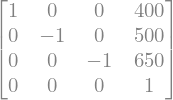

In [2]:
H = Matrix([[1,0,0,400],[0,-1,0,500],[0,0,-1,650],[0,0,0,1]])
H

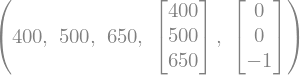

In [3]:
px,py,pz = H[0,3], H[1,3], H[2,3]
re = H[:3,3]
z6 = H[:3,2]
px,py,pz,re,z6

In [4]:
xm,ym,zm = re - 65*z6
xm,ym,zm

In [5]:
Q1 = atan2(ym,xm).evalf()
a = sqrt(xm**2 + ym**2)
r = sqrt((a-70)**2 + (zm-352)**2)
alpha = atan2((zm-352),(a-70))
beta = acos((360**2 + r**2 - 380**2)/(2*360*r))
Q2 = ( alpha - beta ).evalf()
phi = acos((r**2 - 380**2 - 360**2)/(2*380*360))
Q3 = ( phi + pi/2 ).evalf()
Q1,Q2,Q3

In [6]:
IRB140 = Robot((70,pi/2,352,q1), (360,0,0,q2), (0,pi/2,0,q3), (0,-pi/2,380,q4), (0,pi/2,0,q5), (0,0,65,q6))

In [7]:
s1,c1 = symbols("s_1,c_1")
s2,c2 = symbols("s_2,c_2")
s3,c3 = symbols("s_3,c_3")
s4,c4 = symbols("s_4,c_4")
s5,c5 = symbols("s_5,c_5")
s6,c6 = symbols("s_6,c_6")
s23,c23 = symbols("s_{23},c_{23}")

susti = {sin(q1):s1, cos(q1):c1,
         sin(q2):s2, cos(q2):c2,
         sin(q3):s3, cos(q3):c3,
         sin(q4):s4, cos(q4):c4,
         sin(q5):s5, cos(q5):c5,
         sin(q6):s6, cos(q6):c6,
         sin(q2+q3):s23, cos(q2+q3):c23,
        }

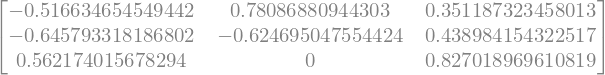

In [8]:
R30 = ( IRB140.T_ij(3,0)[:3,:3] ).subs({q1:Q1, q2:Q2, q3:Q3})
R60 = H[:3,:3]
R63 = IRB140.T_ij(6,3)[:3,:3]
Rx = R30.evalf().inv() * R60
# R63, Rx
R30

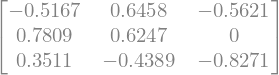

In [9]:
R30 = ( IRB140.T_ij(3,0)[:3,:3] ).subs({q1:rad(51.34), q2:rad(7.78), q3:rad(138.02)})

( R30.evalf().inv() * R60 ).evalf(4)

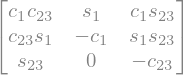

In [10]:
IRB140.T_ij(3,0)[:3,:3].subs(susti)

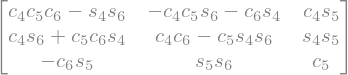

In [11]:
IRB140.T_ij(6,3)[:3,:3].subs(susti)

In [12]:
r33 = Rx[2,2]
r32 = Rx[2,1] 
r31 = Rx[2,0]
r13 = Rx[0,2]
r23 = Rx[1,2]
Q6 = atan2(r32,-r31).evalf()
Q4 = atan2(r23,r13).evalf()
Q5 = atan2(sqrt(1 - r33**2),r33).evalf()
Q4,Q5,Q6

In [17]:
r33 = Rx[2,2]
r32 = Rx[2,1] 
r31 = Rx[2,0]
r13 = Rx[0,2]
r23 = Rx[1,2]
Q6 = atan2(-r32,r31).evalf()
Q4 = atan2(-r23,-r13).evalf()
Q5 = atan2(-sqrt(1 - r33**2),r33).evalf()
Q4,Q5,Q6

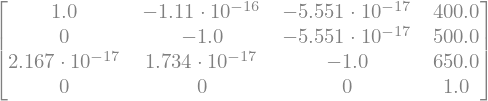

In [18]:
IRB140.T.subs({q1:Q1, q2:Q2, q3:Q3, q4:Q4, q5:Q5, q6:Q6}).evalf(4)

In [19]:
for Q in [Q1,Q2,Q3,Q4,Q5,Q6]:
    print(f"{(Q*180/pi).evalf()}")

51.3401917459099
7.77995012185176
138.013770733804
-2.82879908423551E-15
-145.793720855655
51.3401917459099


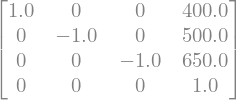

In [16]:
vals = {q1:rad(51.34), q2:rad(7.78), q3:rad(138.02), q4:rad(180), q5:rad(145.8), q6:rad(231.34)}
IRB140.T.subs(vals).evalf(4, chop=True)

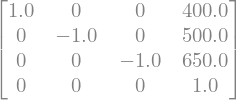

In [20]:
vals = {q1:rad(51.34), q2:rad(7.78), q3:rad(138.02), q4:rad(0), q5:rad(214.2), q6:rad(51.34)}
IRB140.T.subs(vals).evalf(4, chop=True)